In [39]:
!unzip -q data.zip -d ./extracted_data

replace ./extracted_data/data/bad/bad_centered_0.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./extracted_data/data/bad/bad_centered_1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [40]:
!ls ./extracted_data

data


In [41]:
import pandas as pd
import pathlib

In [42]:
data_dir = pathlib.Path('./extracted_data/data')
def load_data(folder_name, label):
    files = list(data_dir.glob(f'{folder_name}/*.csv'))
    df_list = []
    for f in files:
        temp_df = pd.read_csv(f)
        temp_df['label'] = label
        # Add a column for the filename so you can trace back which plot is which
        temp_df['source_file'] = f.name
        df_list.append(temp_df)
    return pd.concat(df_list, ignore_index=True)

# LOAD SEPARATELY
df_train = load_data('good', 1) # Your Golden Set
df_test_outliers = load_data('bad', 0) # Your "Challenge" Set

In [43]:
from sklearn.ensemble import IsolationForest
def get_features(df):
  "flatten the csv into one row of features"
  sig = df['y_signal']
  return {
      'mean': sig.mean(),
      'std': sig.std(),
      'max': sig.max(),
      'min': sig.min(),
      'range': sig.max() - sig.min(),
      'median': sig.median()
  }


  #data prep
def prepare_dataset(folder_path):
  path = pathlib.Path(folder_path)
  feature_list = []
  for f in path.glob('*.csv'):
    df = pd.read_csv(f)
    features = get_features(df)
    feature_list.append(features)
  return pd.DataFrame(feature_list)


#1. load golden set for training
X_train = prepare_dataset('./extracted_data/data/good')

X_test_bad = prepare_dataset('./extracted_data/data/bad')


In [44]:
model = IsolationForest(contamination=0.01, random_state=42)
model.fit(X_train)


results = model.predict(X_test_bad)

anomalies_detected = (results == -1).sum()

print(f"Accuracy on Bad Data: {anomalies_detected / len(X_test_bad):.2%}")

Accuracy on Bad Data: 100.00%


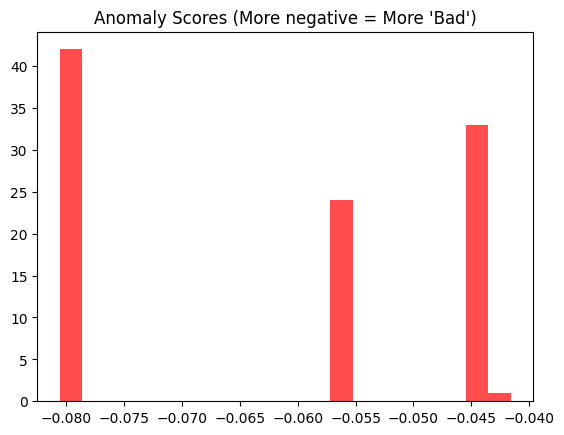

In [45]:
# Get scores for your bad data
scores = model.decision_function(X_test_bad)

# Visualizing the distribution of "weirdness"
import matplotlib.pyplot as plt
plt.hist(scores, bins=20, color='red', alpha=0.7)
plt.title("Anomaly Scores (More negative = More 'Bad')")
plt.show()

In [46]:
def inspect_plot(file_path):
    df = pd.read_csv(file_path)
    features = pd.DataFrame([get_features(df)]) # Using your previous get_features function
    prediction = model.predict(features)[0]
    score = model.decision_function(features)[0]

    status = "PASS" if prediction == 1 else "FAIL"
    print(f"Result for {file_path}: {status} (Score: {score:.4f})")
    return status

# Test it on a random file
inspect_plot('./extracted_data/data/bad/bad_centered_0.csv')

Result for ./extracted_data/data/bad/bad_centered_0.csv: FAIL (Score: -0.0451)


'FAIL'

In [47]:
import random
import numpy as np
import os

def generate_mixed_test_set(n=100, output_dir='data/mixed_test'):
    os.makedirs(output_dir, exist_ok=True)
    x = np.linspace(0, 10, 100)
    ground_truth = []

    for i in range(n):
        # 50/50 chance of generating a good or bad plot
        is_good = random.choice([True, False])
        filename = f"test_sample_{i:03d}.csv"

        # Use your existing logic for linear and exponential background
        y_linear = -x + 10 + np.random.normal(0, 0.1, x.shape)
        y_exponential = np.exp(x / 2.5) / 5 + np.random.normal(0, 0.1, x.shape)

        if is_good:
            curvature = np.random.uniform(0.03, 0.05)
            y_signal = curvature * (x - 4)**2 + 1 + np.random.normal(0, 0.05, x.shape)
            # Upward spikes
            num_spikes = np.random.randint(1, 3)
            for idx in np.random.choice(len(x), num_spikes):
                y_signal[idx] += np.random.uniform(1.0, 4.0)
            label = "GOOD"
        else:
            mode = np.random.choice(['oscillation', 'spikes', 'sawtooth'])
            if mode == 'oscillation':
                y_signal = 2 * np.sin(x * np.random.uniform(3, 6)) + 5
            elif mode == 'spikes':
                y_signal = np.random.normal(5, 0.8, x.shape)
                y_signal[np.random.randint(0, 100, 8)] += np.random.uniform(4, 7)
            else:
                y_signal = (x % 1.5) * 2 + 5
            label = "BAD"

        df = pd.DataFrame({'x': x, 'y_linear': y_linear, 'y_exponential': y_exponential, 'y_signal': y_signal})
        df.to_csv(os.path.join(output_dir, filename), index=False)
        ground_truth.append({'filename': filename, 'actual': label})

    print(f"Generated {n} mixed samples in {output_dir}")
    return pd.DataFrame(ground_truth)

# Generate
df_truth = generate_mixed_test_set()

Generated 100 mixed samples in data/mixed_test


In [48]:
def run_batch_inspection(input_dir, output_report='inspection_results.csv'):
    path = pathlib.Path(input_dir)
    results = []

    for f in path.glob('*.csv'):
        # 1. Load and extract features
        df_sample = pd.read_csv(f)
        feats = pd.DataFrame([get_features(df_sample)])

        # 2. Model Predict
        pred = model.predict(feats)[0]
        score = model.decision_function(feats)[0]

        # 3. Format result
        status = "PASS" if pred == 1 else "FAIL"
        results.append({
            'file_name': f.name,
            'prediction': status,
            'anomaly_score': round(score, 4)
        })

    # Save to CSV
    report_df = pd.DataFrame(results)
    report_df.to_csv(output_report, index=False)
    print(f"Inspection complete! Report saved as {output_report}")
    return report_df

# Run the inspection
df_results = run_batch_inspection('data/mixed_test')

Inspection complete! Report saved as inspection_results.csv


In [52]:
# Merge and check for mismatches
comparison = df_truth.merge(df_results, left_on='filename', right_on='file_name')
mismatches = comparison[((comparison['actual'] == 'GOOD') & (comparison['prediction'] == 'FAIL')) |
                        ((comparison['actual'] == 'BAD') & (comparison['prediction'] == 'PASS'))]

print(f"Total Errors: {len(mismatches)}")
comparison.head(100)

Total Errors: 0


,filename,actual,file_name,prediction,anomaly_score
0,test_sample_000.csv,BAD,test_sample_000.csv,FAIL,-0.0556
1,test_sample_001.csv,GOOD,test_sample_001.csv,PASS,0.0315
2,test_sample_002.csv,BAD,test_sample_002.csv,FAIL,-0.0556
3,test_sample_003.csv,BAD,test_sample_003.csv,FAIL,-0.0451
4,test_sample_004.csv,BAD,test_sample_004.csv,FAIL,-0.0806
...,...,...,...,...,...
95,test_sample_095.csv,BAD,test_sample_095.csv,FAIL,-0.0556
96,test_sample_096.csv,BAD,test_sample_096.csv,FAIL,-0.0556
97,test_sample_097.csv,BAD,test_sample_097.csv,FAIL,-0.0806
98,test_sample_098.csv,GOOD,test_sample_098.csv,PASS,0.1902


In [53]:
# 1. Merge the ground truth (expected) with model results (actual)
comparison = df_truth.merge(df_results, left_on='filename', right_on='file_name')

# 2. Identify specific error types
false_positives = comparison[(comparison['actual'] == 'GOOD') & (comparison['prediction'] == 'FAIL')]
false_negatives = comparison[(comparison['actual'] == 'BAD') & (comparison['prediction'] == 'PASS')]
correct_hits = comparison[comparison['actual'] == comparison['prediction']]

# 3. Calculate Metrics
total = len(comparison)
accuracy = len(correct_hits) / total
fp_rate = len(false_positives) / len(comparison[comparison['actual'] == 'GOOD'])
fn_rate = len(false_negatives) / len(comparison[comparison['actual'] == 'BAD'])

# 4. Print Executive Summary
print(f"{BOLD}--- MODEL PERFORMANCE REPORT ---{ENDC}")
print(f"Total Samples:    {total}")
print(f"Overall Accuracy: {accuracy:.2%}")
print("-" * 30)
print(f"{RED}False Positives:  {len(false_positives)} ({fp_rate:.2%} of Good data flagged as Fail){ENDC}")
print(f"{RED}False Negatives:  {len(false_negatives)} ({fn_rate:.2%} of Bad data missed){ENDC}")
print("-" * 30)

# Show the first 10 mismatches to investigate
if len(mismatches) > 0:
    print(f"\n{BOLD}Top Mismatches (Debugging):{ENDC}")
    print(mismatches[['filename', 'actual', 'prediction', 'anomaly_score']].head(10))

--- MODEL PERFORMANCE REPORT ---
Total Samples:    100
Overall Accuracy: 0.00%
------------------------------
False Positives:  0 (0.00% of Good data flagged as Fail)
False Negatives:  0 (0.00% of Bad data missed)
------------------------------
